PART 1: Data Handling (Data Preprocessing)
Import Required Libraries

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Load dataset
latin1 is used because the file is not UTF-8 encoded.

In [8]:
df = pd.read_csv("laptop_price.csv", encoding="latin1")

Understand the data

In [9]:
df.head()

,ï»¿laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [6]:
df.shape

(1303, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ï»¿laptop_ID      1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [10]:
df.describe()

,ï»¿laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


Check missing values

In [6]:
df.isnull().sum()

ï»¿laptop_ID        0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

Removing unnecessary columns 

Clean and convert numerical columns

In [9]:
df['Ram'] = df['Ram'].str.replace('GB','')
df['Ram'] = df['Ram'].astype(int)

Weight column

In [10]:
df['Weight'] = df['Weight'].str.replace('kg','')
df['Weight'] = df['Weight'].astype(float)

Feature extraction
Extract screen resolution

In [11]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)


Extract CPU brand

In [12]:
def extract_cpu_brand(cpu):
    if 'Intel' in cpu:
        return 'Intel'
    elif 'AMD' in cpu:
        return 'AMD'
    else:
        return 'Other'

df['Cpu_brand'] = df['Cpu'].apply(extract_cpu_brand)


Extract memory type

In [13]:
def memory_type(mem):
    if 'SSD' in mem:
        return 'SSD'
    elif 'HDD' in mem:
        return 'HDD'
    elif 'Flash' in mem:
        return 'Flash Storage'
    else:
        return 'Other'

df['Memory_Type'] = df['Memory'].apply(memory_type)


Drop complex columns

In [11]:
df.drop(columns=['ScreenResolution','Cpu','Memory'], inplace=True)


Encode categorical features
Using One Hot Encoding

In [15]:
df = pd.get_dummies(df, drop_first=True)


PART 2: MODEL BUILDING

Split features and target

In [16]:
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']


Train–Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Build the model
We use Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


PART 3: MODEL EVALUATION

Make predictions

In [19]:
y_pred = model.predict(X_test)


Evaluate model performance

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 202.40045824785295
MSE: 90066.99565784907
RMSE: 300.11163865776524
R2 Score: 0.8226771171300415


Visualization

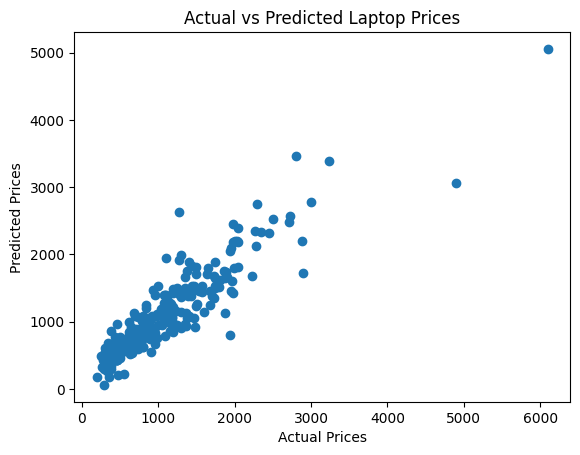

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Laptop Prices")
plt.show()


In [4]:
from sklearn.linear_model import LinearRegression
import pickle




In [6]:


with open("model.pkl", "wb") as file:
    pickle.dump(model, file)


In [7]:
import os
print(os.path.getsize("model.pkl"))


146


In [10]:
import os
print(os.getcwd())


C:\Users\H.H\Untitled Folder 2


In [13]:
import pandas as pd

df = pd.read_csv("laptop_price.csv")
print(df.columns)


Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')


In [14]:

X = df.drop("Price_euros", axis=1)


y = df["Price_euros"]


In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# 1️⃣ Load CSV
df = pd.read_csv("laptop_price.csv")

# 2️⃣ Features & Target
X = df.drop("Price_euros", axis=1)
y = df["Price_euros"]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Model train
model = LinearRegression()
model.fit(X_train, y_train)

# 5️⃣ Save model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

# 6️⃣ Test prediction
example_input = X_test.iloc[0:1]  # first row from test set
prediction = model.predict(example_input)
print("Prediction:", prediction)


Prediction: [1544.36204849]


In [17]:
# Example: new laptop data
new_laptop = {
    'Inches': 15.6,
    'Ram': 16,
    'Memory': '512GB SSD',
    'Price_euros': 0,  # target ko placeholder rakho
    'Company': 'Dell',
    'TypeName': 'Ultrabook',
    'ScreenResolution': '1920x1080',
    'Cpu': 'Intel Core i7',
    'Gpu': 'Intel UHD Graphics 620',
    'OpSys': 'Windows 10',
    'Weight': '1.8kg'
}

# Convert to DataFrame and encode
import pandas as pd
new_df = pd.DataFrame([new_laptop])
new_df = pd.get_dummies(new_df)

# Align columns with training data
new_df = new_df.reindex(columns=X_train.columns, fill_value=0)

# Predict
price_pred = model.predict(new_df)
print("Predicted Price (euros):", price_pred[0])


Predicted Price (euros): 2741.6431978090895
